In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Read the dataset

dataset=pd.read_csv('Customers.csv')

In [3]:
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


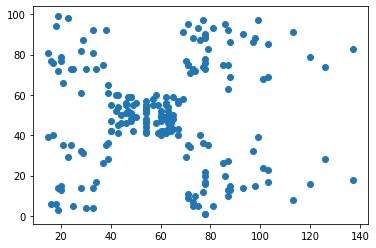

In [4]:
## scatter plot

plt.scatter(dataset['Annual Income (k$)'],dataset['Spending Score (1-100)'])

In [5]:
## Scaling 

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(dataset[['Annual Income (k$)']])
dataset['Annual Income (k$)'] = scaler.transform(dataset[['Annual Income (k$)']])

In [70]:
import pandas as pd

In [71]:
df = pd.read_csv('CC_GENERAL.csv')

In [77]:
import seaborn as sns

In [79]:
df.MINIMUM_PAYMENTS.fillna(df.MINIMUM_PAYMENTS.median(), inplace=True)

In [83]:
df.CREDIT_LIMIT.fillna(df.CREDIT_LIMIT.median(), inplace=True)

In [86]:
df = df.drop(['CUST_ID'], axis=1)

In [90]:
from sklearn.preprocessing import MinMaxScaler

In [91]:
nrm = MinMaxScaler()

In [93]:
df = nrm.fit_transform(df)

In [96]:
from sklearn.cluster import KMeans

In [100]:
import matplotlib.pyplot as plt
%matplotlib inline

---## Standardized ML Pipeline*Auto-generated by Phase 5 ML Standardization***STEP 1** — LazyPredict baseline comparison  **STEP 2** — PyCaret automated pipeline

### STEP 1 — LazyPredict: Baseline Model ComparisonRun all sklearn-compatible models to find the best baseline.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Note: LazyPredict doesn't support clustering directly.
# We'll use sklearn for quick comparison instead.
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

# Prepare features (numeric only)
X = dataset.select_dtypes(include=['number']).dropna()

results = {}
for name, model in [('KMeans', KMeans(n_clusters=3, random_state=42, n_init=10)),
                     ('Agglomerative', AgglomerativeClustering(n_clusters=3))]:
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    results[name] = {'Silhouette Score': round(score, 4)}

results_df = pd.DataFrame(results).T.sort_values('Silhouette Score', ascending=False)
print("=" * 60)
print("Clustering — Baseline Results")
print("=" * 60)
results_df

#### Top Models Visualization

### STEP 2 — PyCaret: Automated ML PipelineFull pipeline with automated preprocessing, model comparison, tuning, and finalization.> **Note:** PyCaret requires Python 3.9–3.11. Install with: `pip install pycaret`

In [ ]:
import sys

# PyCaret setup
try:
    from pycaret.clustering import setup, create_model, assign_model, plot_model, save_model
except ImportError:
    print("PyCaret not installed. Install with: pip install pycaret")
    print("Requires Python 3.9-3.11")
    raise SystemExit("PyCaret required for STEP 2")

# Configure PyCaret session — clustering (no target)
clust_setup = setup(
    data=dataset.select_dtypes(include=['number']).dropna(),
    session_id=42,
    verbose=False,
)
print("PyCaret clustering setup complete.")

In [ ]:
# Create KMeans model
kmeans = create_model('kmeans', num_clusters=3)
print(kmeans)

In [ ]:
# Assign cluster labels
clustered_df = assign_model(kmeans)
print(clustered_df.head())

#### Model Evaluation

In [ ]:
# Cluster visualization
try:
    plot_model(kmeans, plot='cluster', save=True)
    plot_model(kmeans, plot='elbow', save=True)
except Exception as e:
    print(f"Plot generation note: {e}")

#### Save Model Pipeline

In [ ]:
# Save the clustering pipeline
save_model(kmeans, 'clustering_pipeline')
print("Clustering model saved as 'clustering_pipeline.pkl'")